# Correlation Analysis Per Video: MoLab Features vs IRAF SAT (n=10)

In [28]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import os

MOLAB_DIR     = Path('../data/processed/molab_cropped')
FEATURES_DIR  = '../data/processed/features/'
OUT_DIR     = '../data/processed/features/molab/per_video/'
os.makedirs(OUT_DIR, exist_ok=True)

KORS_PATH   = '../data/original/Forts_IRAF_SAT_Kors.xlsx'
RAK_PATH    = '../data/original/Forts_IRAF_SAT_RAK.xlsx'

TIME_DICT = {
    '0028': (9.90, 10.40, 10.50, 11.12, 11.19, 11.77),
    '0030': (5.80, 6.25, 6.32,  6.70,  6.76,  7.63),
    '0045': (6.54, 6.70, 6.70,  7.29,  7.45,  7.98),
    '0047': (7.03, 7.41, 7.49,  7.79,  7.97,  8.91),
    '0059': (6.65, 6.88, 6.90,  7.96,  8.19,  9.11),
    '0061': (7.00, 7.40, 7.45,  8.10,  8.20,  9.00),
    '0074': (6.07, 6.33, 6.35,  6.71,  6.90,  7.27),
    '0076': (5.20, 5.80, 5.90,  6.30,  6.40,  7.30),
    '0091': (6.39, 6.55, 6.60,  7.03,  7.18,  7.61),
    '0093': (5.86, 5.92, 6.20,  6.65,  6.92,  7.67),
}

In [29]:
def parse_iraf_per_video(xl, sheet_name, fp_videos=None):
    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].astype(str)
    film_rows = raw.index[col0.str.contains('Film Nr', na=False)].tolist()
    film_rows.append(len(raw))
    records = []
    phase_weight_records = []
    for i, start in enumerate(film_rows[:-1]):
        video = col0.iloc[start].split(': ')[1].strip().zfill(3)
        block = raw.iloc[start:film_rows[i+1]]
        bc0 = block.iloc[:, 0].astype(str)
        up_idx = bc0[bc0.str.strip() == 'Utgångsposition'].index
        rs_idx = bc0[bc0.str.strip() == 'Rörelsestart'].index
        ru_idx = bc0[bc0.str.strip() == 'Rörelseutförande'].index
        if not (len(up_idx) and len(rs_idx) and len(ru_idx)):
            continue
        up_i, rs_i, ru_i = up_idx[0], rs_idx[0], ru_idx[0]
        end_i = film_rows[i+1]
        for phase, p_i in [('utgångsposition', up_i), ('rörelsestart', rs_i), ('rörelseutförande', ru_i)]:
            phase_weight_records.append({'video': video, 'phase': phase, 'phase_weight': raw.iloc[p_i, 1]})
        for phase, p_start, p_end in [
            ('utgångsposition', up_i+1, rs_i),
            ('rörelsestart',    rs_i+1, ru_i),
            ('rörelseutförande', ru_i+1, end_i)
        ]:
            for _, r in raw.iloc[p_start:p_end].iterrows():
                weight = pd.to_numeric(r[1], errors='coerce')
                avvik  = pd.to_numeric(r[3], errors='coerce')
                if pd.notna(weight) and pd.notna(avvik) and str(r[5]).strip().lower() != 'x':
                    records.append({'video': video, 'phase': phase,
                                    'weight': weight, 'avvikelse': float(avvik)})
    return pd.DataFrame(records), pd.DataFrame(phase_weight_records)

kors_xl = pd.ExcelFile(KORS_PATH)
rak_xl  = pd.ExcelFile(RAK_PATH)
kors_df, kors_pw = parse_iraf_per_video(kors_xl, 'Sittande till stående')
rak_df,  rak_pw  = parse_iraf_per_video(rak_xl,  'Sittande till stående')
iraf_raw = pd.concat([kors_df, rak_df], ignore_index=True)
iraf_raw = iraf_raw.assign(w=iraf_raw['avvikelse'] * iraf_raw['weight'])

phase_weights = pd.concat([kors_pw, rak_pw]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv = iraf_raw.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv.columns.name = None
iraf_pv.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv.columns[1:]]

total_w = sum(phase_weights.values())
iraf_pv['iraf_total'] = sum(iraf_pv[f'iraf_{p}'] * w for p, w in phase_weights.items()) / total_w

iraf_pv

,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,028,2.0,0.6875,1.047619,1.314732
1,030,0.0,0.0000,0.052632,0.019737
2,045,2.0,0.9375,1.142857,1.412946
3,047,0.0,0.3125,0.619048,0.310268
4,059,2.0,0.9375,1.238095,1.448661
5,061,0.0,0.1250,0.263158,0.129934
6,074,2.0,0.9375,1.285714,1.466518
7,076,0.0,0.5625,0.095238,0.176339
8,091,1.0,0.6875,1.571429,1.136161
9,093,1.0,0.3125,0.421053,0.611020


In [30]:
def get_phase(df, t_start, t_end):
    return df[(df['video_time'] >= t_start) & (df['video_time'] <= t_end)]

def rms(x): return np.sqrt(np.mean(x**2))

def extract_utgångsposition(df, t0, t1):
    p = get_phase(df, t0, t1)
    lk, rk = p['JointAngle/L_knee_X'], p['JointAngle/R_knee_X']
    return {
        'mean_L_knee_flexion':  lk.mean(),
        'mean_R_knee_flexion':  rk.mean(),
        'delta_knee_asymmetry': abs(lk.mean() - rk.mean()),
        'mean_L_hip_flexion':   p['JointAngle/L_hip_X'].mean(),
        'mean_R_hip_flexion':   p['JointAngle/R_hip_X'].mean(),
        'mean_pelvis_tilt':     p['JointAngle/pelvis_X'].mean(),
        'mean_pelvis_lateral':  p['JointAngle/pelvis_Y'].abs().mean(),
    }

def extract_rörelsestart(df, t1, t5):
    p = get_phase(df, t1, t5)
    pelvis_x, gyro_y = p['JointAngle/pelvis_X'], p['SegmentGyro/pelvis_Y']
    return {
        'initial_pelvis_tilt': pelvis_x.iloc[0] if len(pelvis_x) else np.nan,
        'max_pelvis_tilt':     pelvis_x.max(),
        'delta_pelvis_tilt':   pelvis_x.max() - pelvis_x.min(),
        'peak_pelvis_gyro':    gyro_y.abs().max(),
        'mean_pelvis_gyro':    gyro_y.abs().mean(),
        'hip_flexion_range':   ((p['JointAngle/L_hip_X'].max() - p['JointAngle/L_hip_X'].min()) +
                                (p['JointAngle/R_hip_X'].max() - p['JointAngle/R_hip_X'].min())) / 2,
        'rms_pelvis_acc':      rms(p['SegmentAcc/pelvis_Y'].values),
    }

def extract_rörelseutförande(df, t2, t3, t4, t5):
    forb, uppr = get_phase(df, t2, t3), get_phase(df, t4, t5)
    lk_up, rk_up = uppr['JointAngle/L_knee_X'], uppr['JointAngle/R_knee_X']
    return {
        'forb_delta_pelvis_tilt':    forb['JointAngle/pelvis_X'].max() - forb['JointAngle/pelvis_X'].min(),
        'forb_peak_pelvis_gyro':     forb['SegmentGyro/pelvis_Y'].abs().max(),
        'forb_rms_pelvis_acc':       rms(forb['SegmentAcc/pelvis_Y'].values),
        'uppr_total_knee_extension': ((lk_up.max() - lk_up.min()) + (rk_up.max() - rk_up.min())) / 2,
        'uppr_peak_shank_gyro':      max(uppr['SegmentGyro/L_shank_Y'].abs().max(),
                                         uppr['SegmentGyro/R_shank_Y'].abs().max()),
        'uppr_total_hip_extension':  ((uppr['JointAngle/L_hip_X'].max() - uppr['JointAngle/L_hip_X'].min()) +
                                      (uppr['JointAngle/R_hip_X'].max() - uppr['JointAngle/R_hip_X'].min())) / 2,
    }


In [31]:
feat_up = pd.read_csv(FEATURES_DIR + 'molab_utgångsposition.csv')
feat_rs = pd.read_csv(FEATURES_DIR + 'molab_rörelsestart.csv')
feat_ru = pd.read_csv(FEATURES_DIR + 'molab_rörelseutförande.csv')
for df in [feat_up, feat_rs, feat_ru]:
    df['video'] = df['video'].astype(str).str.zfill(3)

merged_up = feat_up.merge(iraf_pv[['video', 'iraf_utgångsposition']].rename(columns={'iraf_utgångsposition': 'iraf_score'}), on='video')
merged_rs = feat_rs.merge(iraf_pv[['video', 'iraf_rörelsestart']].rename(columns={'iraf_rörelsestart': 'iraf_score'}), on='video')
merged_ru = feat_ru.merge(iraf_pv[['video', 'iraf_rörelseutförande']].rename(columns={'iraf_rörelseutförande': 'iraf_score'}), on='video')
print(f'n per phase   up:{len(merged_up)}, rs:{len(merged_rs)}, ru:{len(merged_ru)}')


n per phase   up:10, rs:10, ru:10


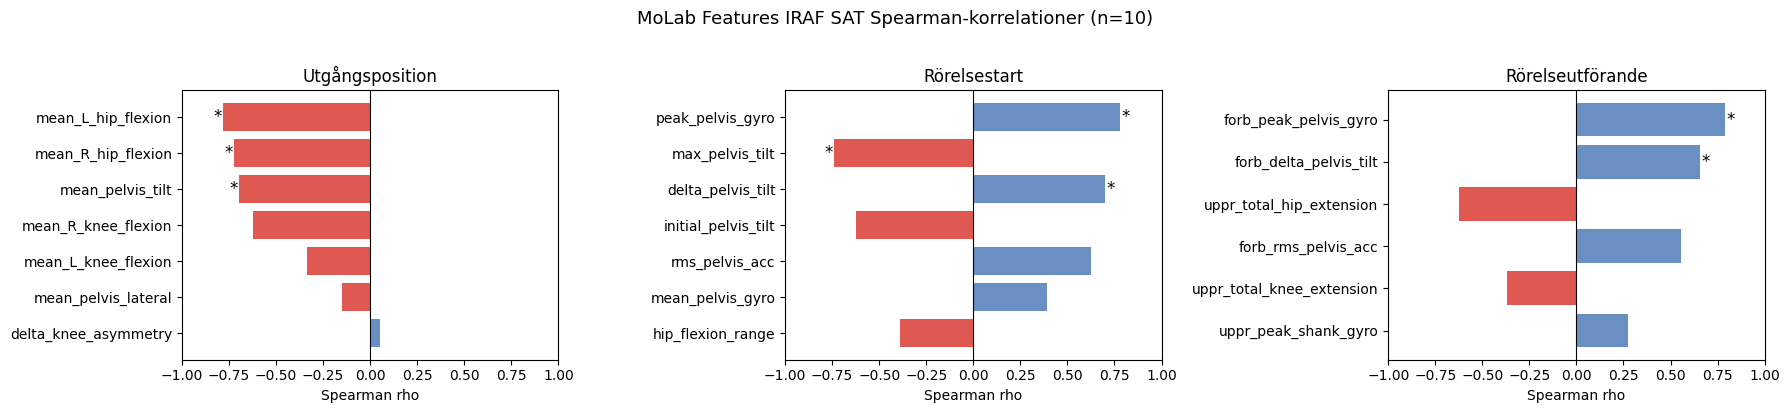

In [32]:
def spearman(df):
    result = pd.DataFrame([
        {'feature': c, 'rho': stats.spearmanr(df[c], df['iraf_score'])[0],
                       'p':   stats.spearmanr(df[c], df['iraf_score'])[1]}
        for c in df.columns if c not in ['video', 'iraf_score']
        if df[[c, 'iraf_score']].dropna().__len__() >= 3
    ])
    return result.sort_values('rho', key=abs, ascending=False) if len(result) else result

corr_up = spearman(merged_up)
corr_rs = spearman(merged_rs)
corr_ru = spearman(merged_ru)

corr_up.to_csv(OUT_DIR + 'corr_utgångsposition.csv', index=False)
corr_rs.to_csv(OUT_DIR + 'corr_rörelsestart.csv', index=False)
corr_ru.to_csv(OUT_DIR + 'corr_rörelseutförande.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, corr, title in zip(axes, [corr_up, corr_rs, corr_ru], ['Utgångsposition', 'Rörelsestart', 'Rörelseutförande']):
    c = corr.set_index('feature')
    ax.barh(c.index, c['rho'], color=['#d73027' if r < 0 else '#4575b4' for r in c['rho']], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(c.iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + (0.03 if row['rho'] >= 0 else -0.03), i, '*', ha='center', va='center', fontsize=12)
plt.suptitle('MoLab Features IRAF SAT Spearman-korrelationer (n=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR + 'molab_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


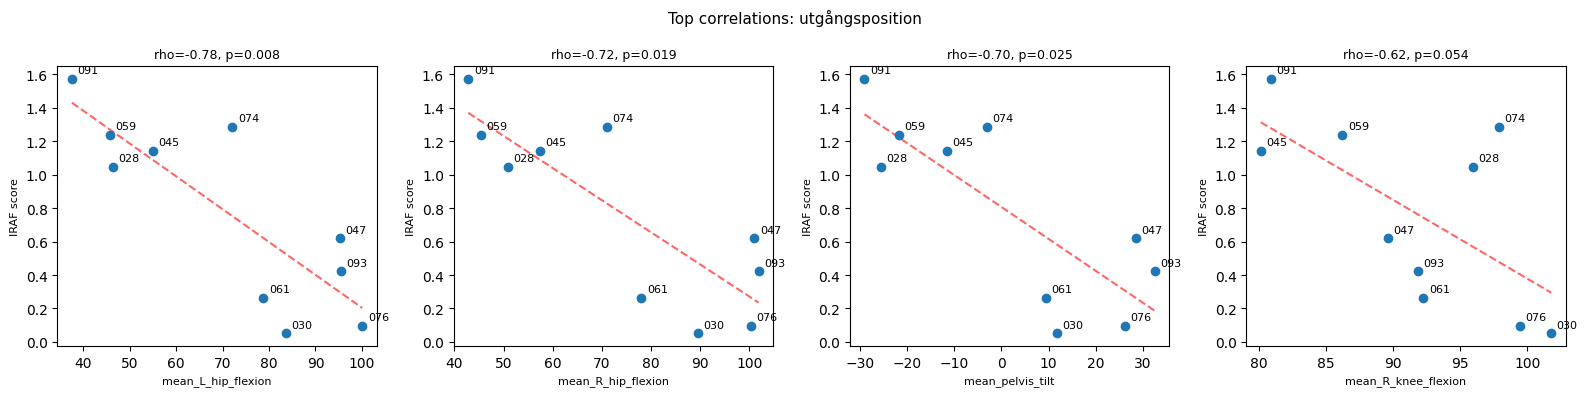

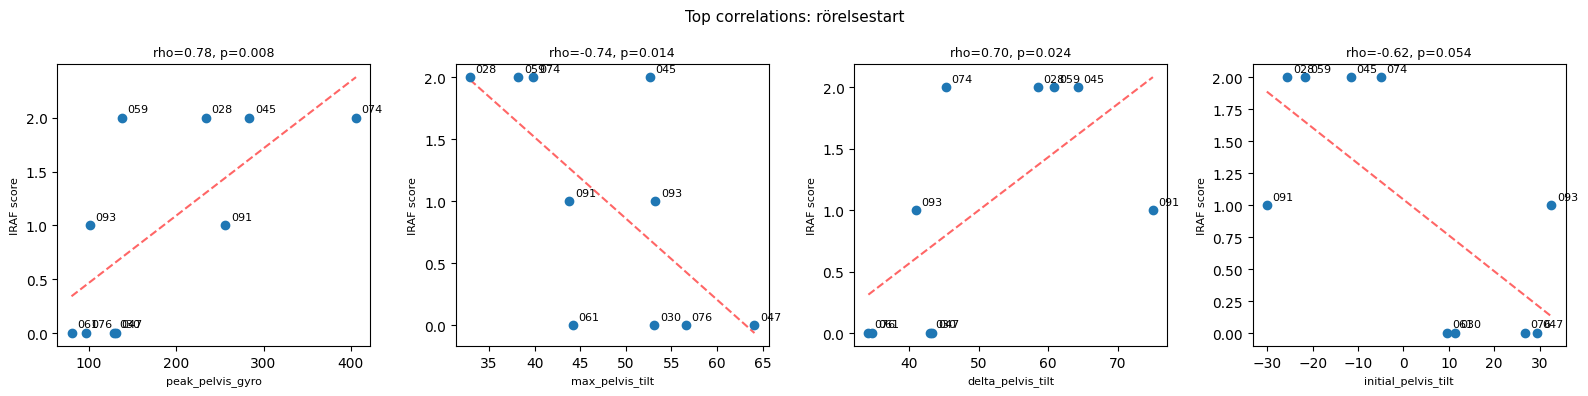

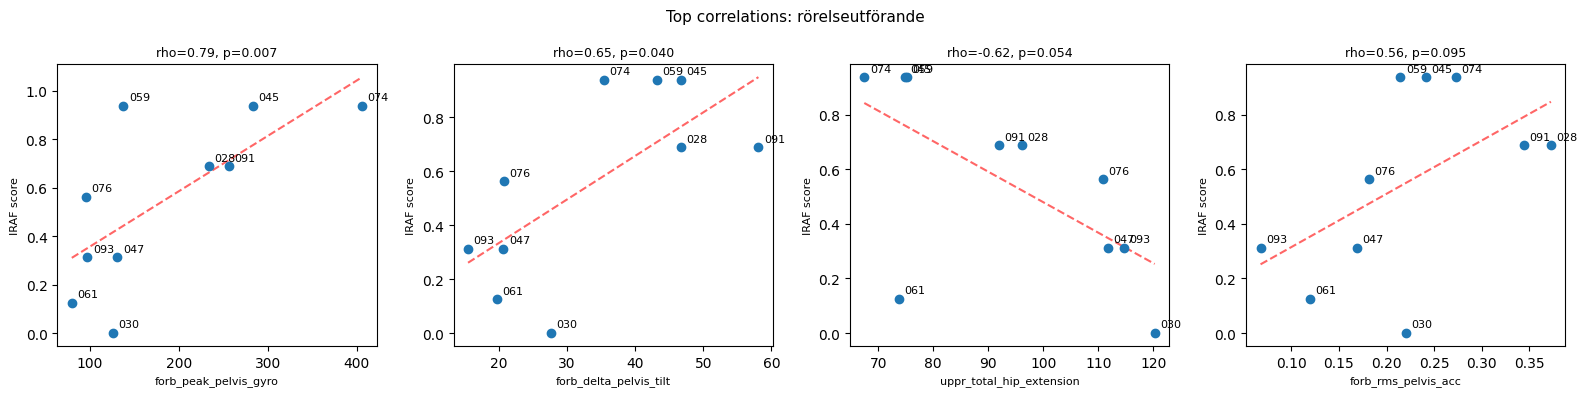

In [33]:
def plot_top_scatters(merged_df, corr_df, phase_name, n_top=4, out_dir=None):
    top = corr_df.head(n_top)
    fig, axes = plt.subplots(1, len(top), figsize=(4*len(top), 4))
    if len(top) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, top.iterrows()):
        fc = row['feature']
        vals = merged_df[['video', fc, 'iraf_score']].dropna()
        ax.scatter(vals[fc], vals['iraf_score'], zorder=3)
        for _, r in vals.iterrows():
            ax.annotate(r['video'], (r[fc], r['iraf_score']),
                        textcoords='offset points', xytext=(4, 4), fontsize=8)
        m, b = np.polyfit(vals[fc], vals['iraf_score'], 1)
        xr = np.linspace(vals[fc].min(), vals[fc].max(), 50)
        ax.plot(xr, m*xr+b, 'r--', alpha=0.6)
        ax.set_xlabel(fc, fontsize=8)
        ax.set_ylabel('IRAF score', fontsize=8)
        ax.set_title(f'rho={row["rho"]:.2f}, p={row["p"]:.3f}', fontsize=9)
    if out_dir is None:
        out_dir = OUT_DIR
    fig.suptitle(f'Top correlations: {phase_name}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{out_dir}molab_scatter_{phase_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_top_scatters(merged_up, corr_up, 'utgångsposition')
plot_top_scatters(merged_rs, corr_rs, 'rörelsestart')
plot_top_scatters(merged_ru, corr_ru, 'rörelseutförande')


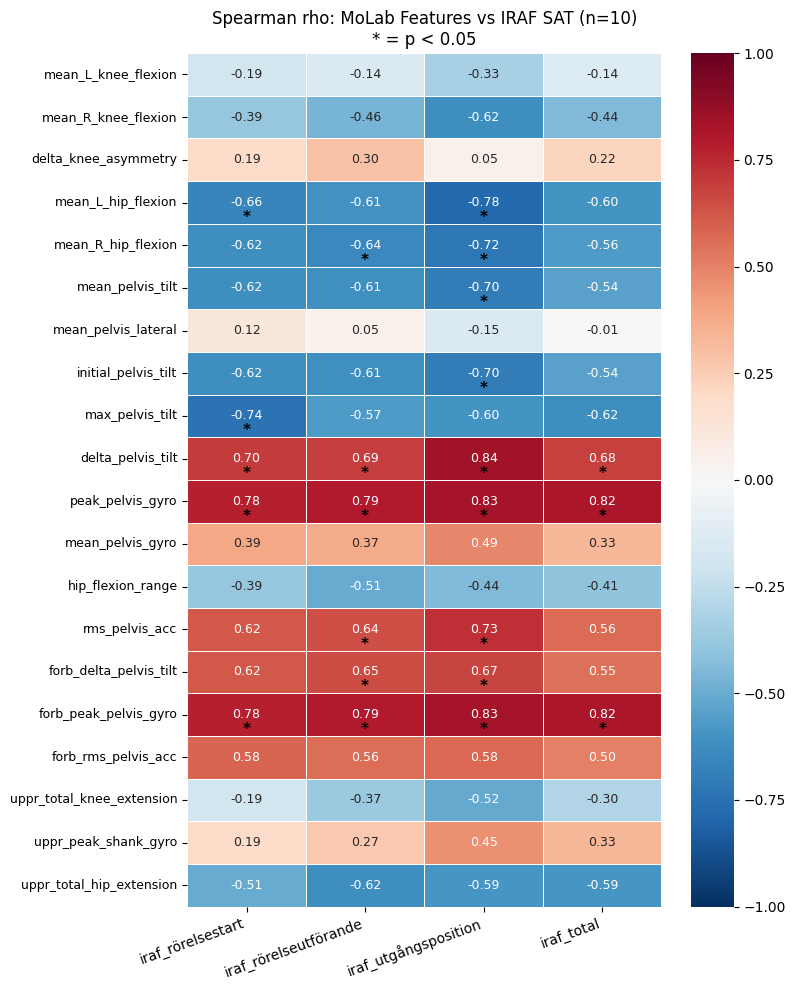

In [34]:
all_feats = feat_up.merge(feat_rs, on='video', how='outer').merge(feat_ru, on='video', how='outer')
merged_all = all_feats.merge(iraf_pv, on='video')

feat_cols = [c for c in all_feats.columns if c != 'video']
iraf_cols = [c for c in iraf_pv.columns if c != 'video']

rho_mat = pd.DataFrame(index=feat_cols, columns=iraf_cols, dtype=float)
p_mat   = pd.DataFrame(index=feat_cols, columns=iraf_cols, dtype=float)
for fc in feat_cols:
    for ic in iraf_cols:
        vals = merged_all[[fc, ic]].dropna()
        if len(vals) >= 3:
            rho_mat.loc[fc, ic], p_mat.loc[fc, ic] = stats.spearmanr(vals[fc], vals[ic])

fig, ax = plt.subplots(figsize=(8, max(8, len(feat_cols) * 0.5)))
sns.heatmap(rho_mat.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, mask=rho_mat.isna(), annot_kws={'size': 9})
for i, fc in enumerate(feat_cols):
    for j, ic in enumerate(iraf_cols):
        if pd.notna(p_mat.loc[fc, ic]) and p_mat.loc[fc, ic] < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Spearman rho: MoLab Features vs IRAF SAT (n=10)\n* = p < 0.05', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR + 'molab_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [35]:
corr_results = pd.DataFrame([
    {'feature': fc, 'iraf_score': ic, 'spearman_rho': rho_mat.loc[fc, ic], 'p_value': p_mat.loc[fc, ic]}
    for fc in feat_cols for ic in iraf_cols
    if pd.notna(rho_mat.loc[fc, ic])
]).sort_values('spearman_rho', key=abs, ascending=False)

corr_results.to_csv(OUT_DIR + 'molab_correlation_results.csv', index=False)
print(f'{len(corr_results)} correlations saved')
corr_results.head(10)


80 correlations saved


,feature,iraf_score,spearman_rho,p_value
38,delta_pelvis_tilt,iraf_utgångsposition,0.842424,0.002220
42,peak_pelvis_gyro,iraf_utgångsposition,0.830303,0.002940
62,forb_peak_pelvis_gyro,iraf_utgångsposition,0.830303,0.002940
43,peak_pelvis_gyro,iraf_total,0.818182,0.003815
63,forb_peak_pelvis_gyro,iraf_total,0.818182,0.003815
61,forb_peak_pelvis_gyro,iraf_rörelseutförande,0.790259,0.006516
41,peak_pelvis_gyro,iraf_rörelseutförande,0.790259,0.006516
14,mean_L_hip_flexion,iraf_utgångsposition,-0.781818,0.007547
40,peak_pelvis_gyro,iraf_rörelsestart,0.778499,0.007982
60,forb_peak_pelvis_gyro,iraf_rörelsestart,0.778499,0.007982


## Stående till sittande (Stand-to-Sit)

In [36]:
DOWN_FEATURES_DIR_M = '../data/processed/features_down/'
DOWN_OUT_DIR_MOLAB  = '../data/processed/features_down/molab/per_video/'
os.makedirs(DOWN_OUT_DIR_MOLAB, exist_ok=True)
RAK_DOWN_FP_VIDEOS  = ['030', '047', '061', '076', '093']

kors_df_d, kors_pw_d = parse_iraf_per_video(kors_xl, 'Stående till sittande')
rak_df_d,  rak_pw_d  = parse_iraf_per_video(rak_xl,  'Stående till sittande', fp_videos=RAK_DOWN_FP_VIDEOS)
iraf_raw_d = pd.concat([kors_df_d, rak_df_d], ignore_index=True)
iraf_raw_d = iraf_raw_d.assign(w=iraf_raw_d['avvikelse'] * iraf_raw_d['weight'])

phase_weights_d = pd.concat([kors_pw_d, rak_pw_d]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv_d = iraf_raw_d.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv_d.columns.name = None
iraf_pv_d.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv_d.columns[1:]]

total_w_d = sum(phase_weights_d.values())
iraf_pv_d['iraf_total'] = sum(iraf_pv_d[f'iraf_{p}'] * w for p, w in phase_weights_d.items()) / total_w_d

iraf_pv_d


,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,028,0.0,0.333333,0.352941,0.246499
1,030,0.0,0.333333,0.000000,0.095238
2,045,1.0,0.777778,0.863636,0.878066
3,047,0.0,0.444444,0.428571,0.310658
4,059,0.0,0.333333,0.466667,0.295238
5,061,0.0,0.166667,0.352941,0.198880
6,074,1.0,0.611111,0.684211,0.753551
7,076,1.0,0.611111,0.777778,0.793651
8,091,0.0,0.611111,0.727273,0.486291
9,093,0.0,0.500000,0.947368,0.548872


In [37]:
feat_up_d = pd.read_csv(DOWN_FEATURES_DIR_M + 'down_molab_utgångsposition.csv')
feat_rs_d = pd.read_csv(DOWN_FEATURES_DIR_M + 'down_molab_rörelsestart.csv')
feat_ru_d = pd.read_csv(DOWN_FEATURES_DIR_M + 'down_molab_rörelseutförande.csv')
for df in [feat_up_d, feat_rs_d, feat_ru_d]:
    df['video'] = df['video'].astype(str).str.zfill(3)

merged_up_d = feat_up_d.merge(iraf_pv_d[['video', 'iraf_utgångsposition']].rename(columns={'iraf_utgångsposition': 'iraf_score'}), on='video')
merged_rs_d = feat_rs_d.merge(iraf_pv_d[['video', 'iraf_rörelsestart']].rename(columns={'iraf_rörelsestart': 'iraf_score'}), on='video')
merged_ru_d = feat_ru_d.merge(iraf_pv_d[['video', 'iraf_rörelseutförande']].rename(columns={'iraf_rörelseutförande': 'iraf_score'}), on='video')
print(f'n per phase   up:{len(merged_up_d)}, rs:{len(merged_rs_d)}, ru:{len(merged_ru_d)}')


n per phase   up:10, rs:10, ru:10


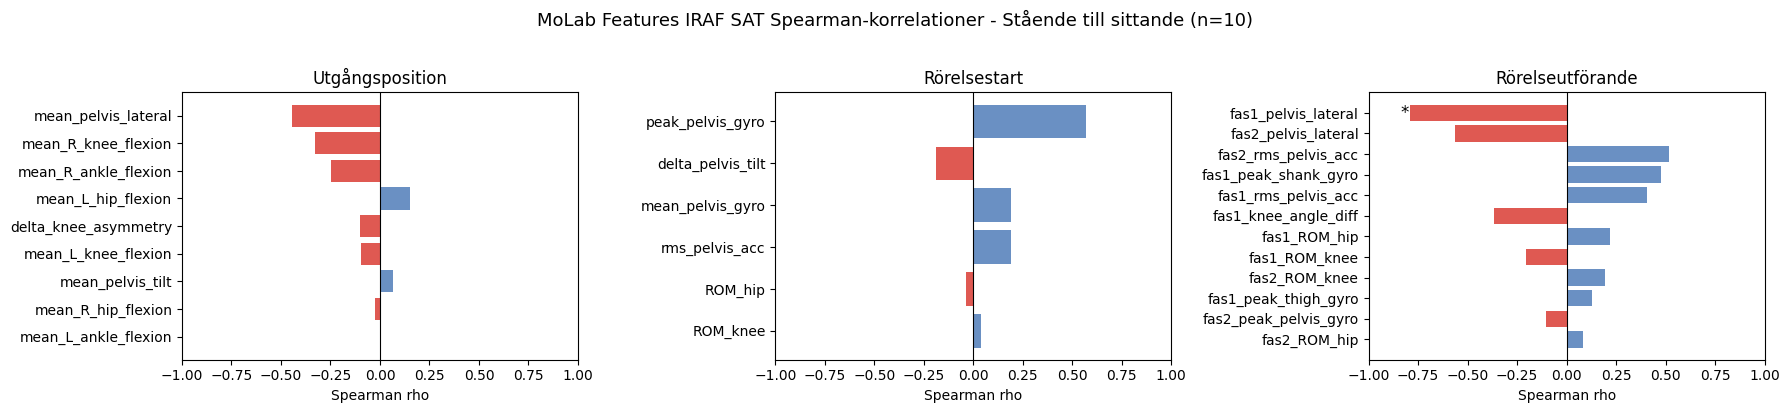

In [38]:
corr_up_d = spearman(merged_up_d)
corr_rs_d = spearman(merged_rs_d)
corr_ru_d = spearman(merged_ru_d)

corr_up_d.to_csv(DOWN_OUT_DIR_MOLAB + 'corr_utgångsposition.csv', index=False)
corr_rs_d.to_csv(DOWN_OUT_DIR_MOLAB + 'corr_rörelsestart.csv', index=False)
corr_ru_d.to_csv(DOWN_OUT_DIR_MOLAB + 'corr_rörelseutförande.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, corr, title in zip(axes, [corr_up_d, corr_rs_d, corr_ru_d], ['Utgångsposition', 'Rörelsestart', 'Rörelseutförande']):
    c = corr.set_index('feature')
    ax.barh(c.index, c['rho'], color=['#d73027' if r < 0 else '#4575b4' for r in c['rho']], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(c.iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + (0.03 if row['rho'] >= 0 else -0.03), i, '*', ha='center', va='center', fontsize=12)
plt.suptitle('MoLab Features IRAF SAT Spearman-korrelationer - Stående till sittande (n=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOWN_OUT_DIR_MOLAB + 'molab_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


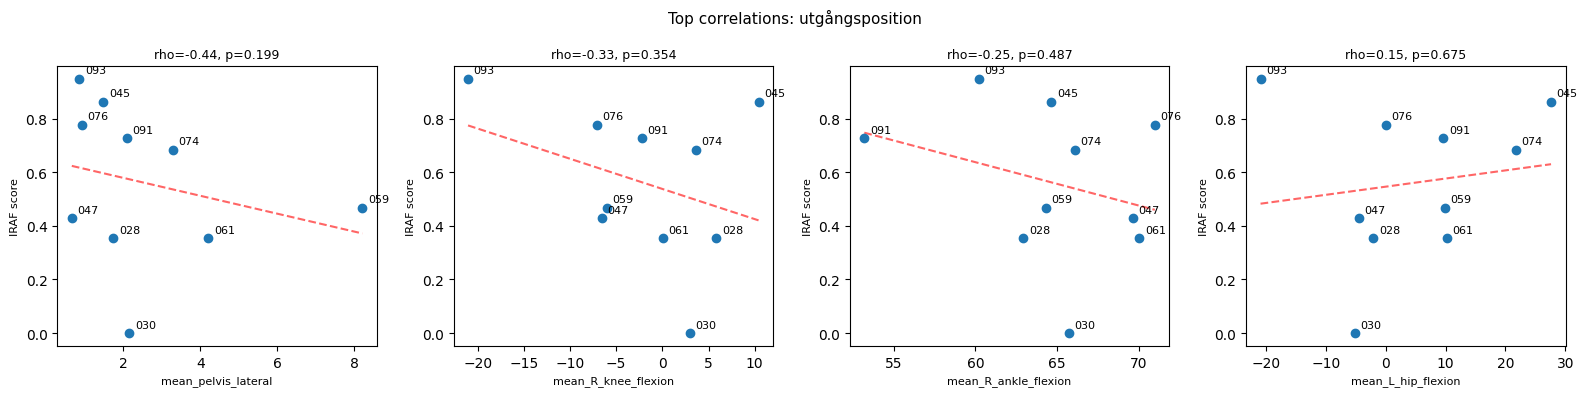

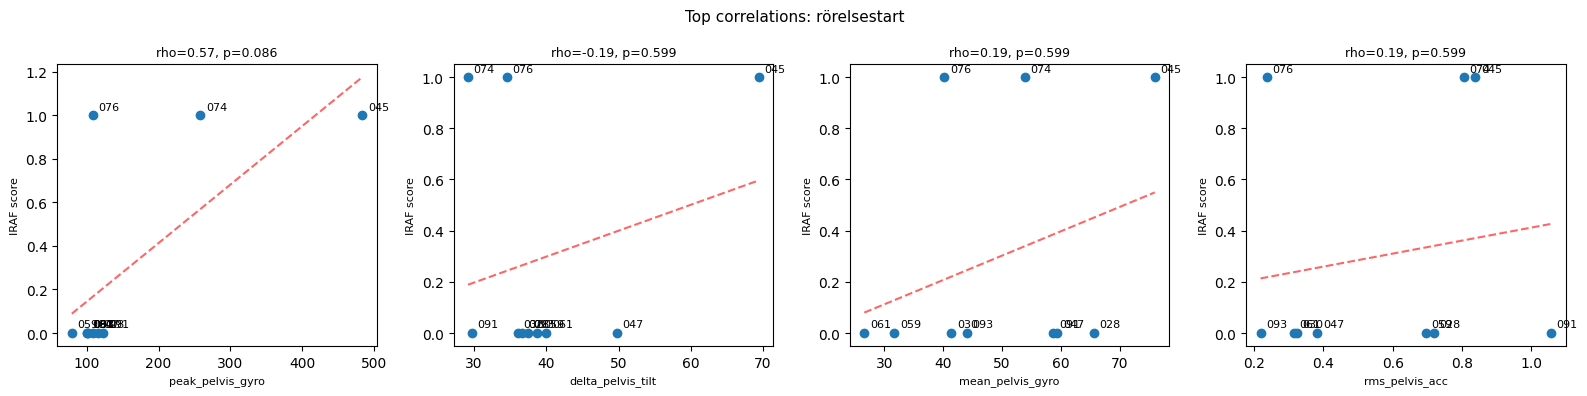

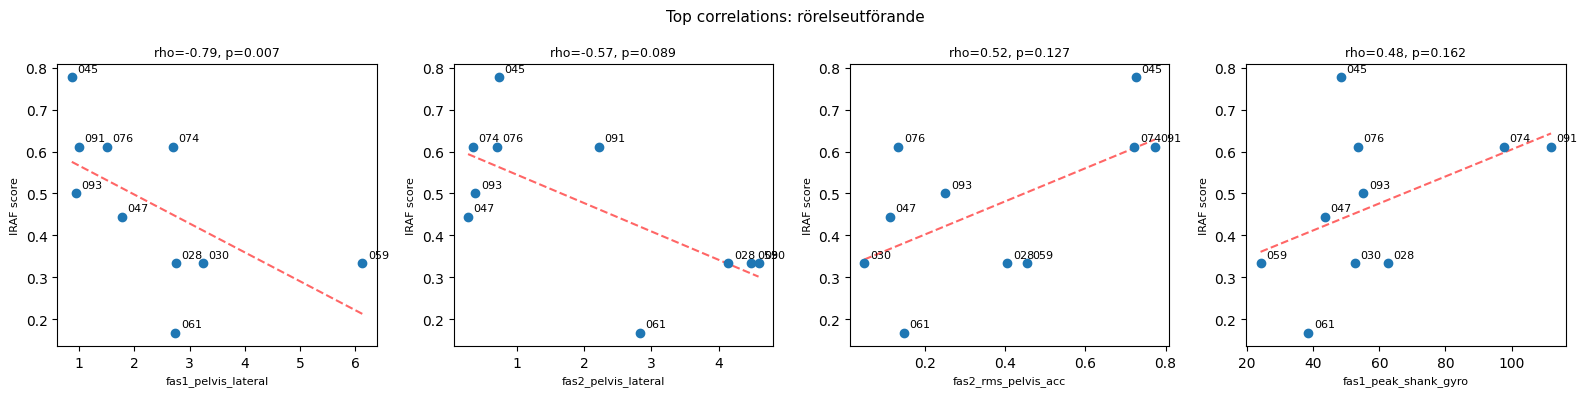

In [39]:
plot_top_scatters(merged_up_d, corr_up_d, 'utgångsposition', out_dir=DOWN_OUT_DIR_MOLAB)
plot_top_scatters(merged_rs_d, corr_rs_d, 'rörelsestart',    out_dir=DOWN_OUT_DIR_MOLAB)
plot_top_scatters(merged_ru_d, corr_ru_d, 'rörelseutförande', out_dir=DOWN_OUT_DIR_MOLAB)


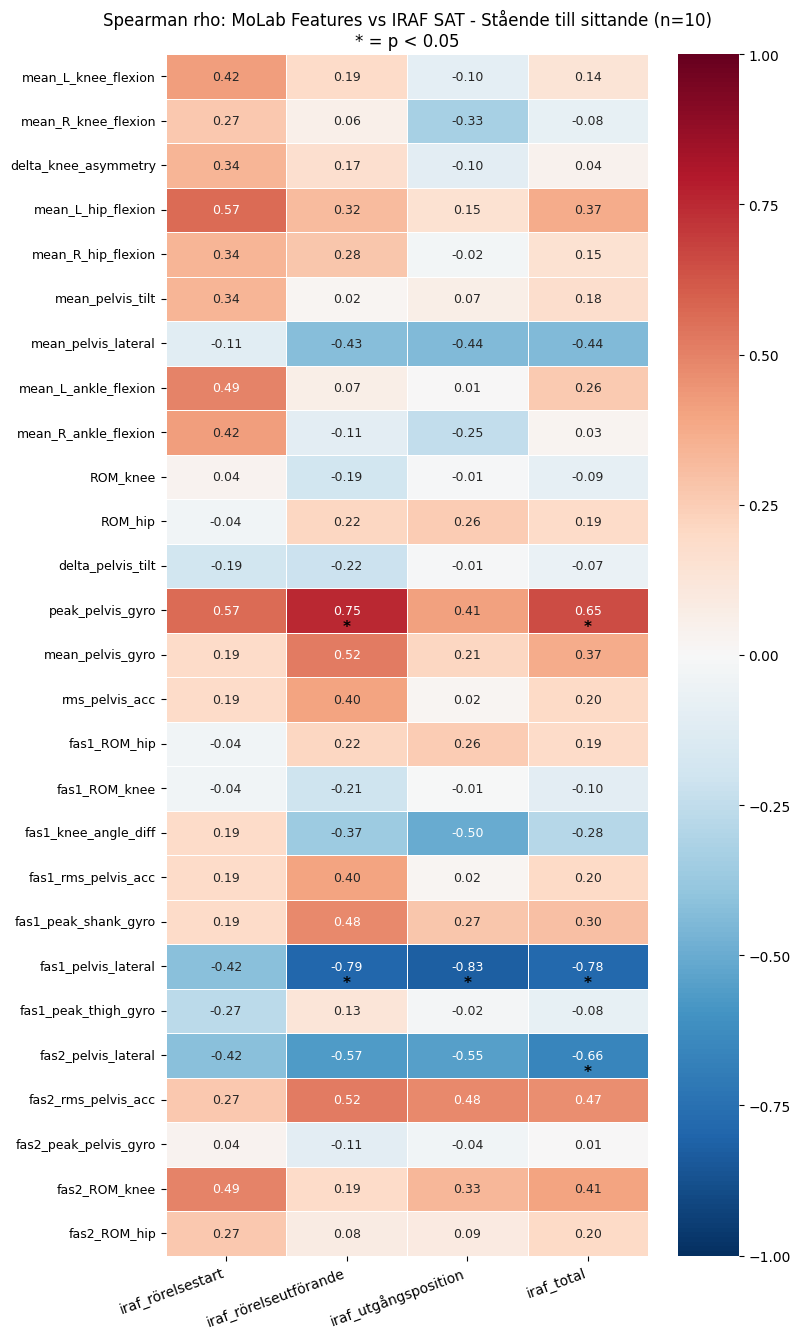

In [40]:
all_feats_d = feat_up_d.merge(feat_rs_d, on='video', how='outer').merge(feat_ru_d, on='video', how='outer')
merged_all_d = all_feats_d.merge(iraf_pv_d, on='video')

feat_cols_d = [c for c in all_feats_d.columns if c != 'video']
iraf_cols_d = [c for c in iraf_pv_d.columns if c != 'video']

rho_mat_d = pd.DataFrame(index=feat_cols_d, columns=iraf_cols_d, dtype=float)
p_mat_d   = pd.DataFrame(index=feat_cols_d, columns=iraf_cols_d, dtype=float)
for fc in feat_cols_d:
    for ic in iraf_cols_d:
        vals = merged_all_d[[fc, ic]].dropna()
        if len(vals) >= 3:
            rho_mat_d.loc[fc, ic], p_mat_d.loc[fc, ic] = stats.spearmanr(vals[fc], vals[ic])

fig, ax = plt.subplots(figsize=(8, max(8, len(feat_cols_d) * 0.5)))
sns.heatmap(rho_mat_d.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, mask=rho_mat_d.isna(), annot_kws={'size': 9})
for i, fc in enumerate(feat_cols_d):
    for j, ic in enumerate(iraf_cols_d):
        if pd.notna(p_mat_d.loc[fc, ic]) and p_mat_d.loc[fc, ic] < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Spearman rho: MoLab Features vs IRAF SAT - Stående till sittande (n=10)\n* = p < 0.05', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(DOWN_OUT_DIR_MOLAB + 'molab_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [41]:
corr_results_d = pd.DataFrame([
    {'feature': fc, 'iraf_score': ic, 'spearman_rho': rho_mat_d.loc[fc, ic], 'p_value': p_mat_d.loc[fc, ic]}
    for fc in feat_cols_d for ic in iraf_cols_d
    if pd.notna(rho_mat_d.loc[fc, ic])
]).sort_values('spearman_rho', key=abs, ascending=False)

corr_results_d.to_csv(DOWN_OUT_DIR_MOLAB + 'molab_correlation_results.csv', index=False)
print(f'{len(corr_results_d)} correlations saved')
corr_results_d.head(10)


108 correlations saved


,feature,iraf_score,spearman_rho,p_value
82,fas1_pelvis_lateral,iraf_utgångsposition,-0.826752,0.003180
81,fas1_pelvis_lateral,iraf_rörelseutförande,-0.789063,0.006656
83,fas1_pelvis_lateral,iraf_total,-0.781818,0.007547
49,peak_pelvis_gyro,iraf_rörelseutförande,0.751785,0.012154
91,fas2_pelvis_lateral,iraf_total,-0.660606,0.037588
51,peak_pelvis_gyro,iraf_total,0.648485,0.042540
12,mean_L_hip_flexion,iraf_rörelsestart,0.569803,0.085504
48,peak_pelvis_gyro,iraf_rörelsestart,0.569803,0.085504
89,fas2_pelvis_lateral,iraf_rörelseutförande,-0.565392,0.088509
90,fas2_pelvis_lateral,iraf_utgångsposition,-0.547115,0.101678
